# NK Cell AP-1 + Exhaustion Score Analysis
## Addresses Reviewer Comment 16
**Analyses:**
1. AP-1 family expression across disease stages (HD → MGUS → SMM → MM)
2. NK exhaustion score across disease stages
3. Patient/cell counts per condition

In [1]:
# ============================================================
# CELL 1A: INSTALL  (restarts the runtime the first time it runs)
# ============================================================
import importlib.util, subprocess, sys, os

if importlib.util.find_spec("scanpy") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "scanpy", "anndata", "scikit-learn"], check=True)
    print("Installed — restarting runtime, then run CELL 2.")
    os.kill(os.getpid(), 9)      # forces a kernel restart
else:
    print("scanpy already available — go straight to CELL 2.")

scanpy already available — go straight to CELL 2.


In [3]:
# ============================================================
# CELL 1B: SETUP & DATA LOADING
# ============================================================
!pip -q install scanpy anndata scikit-learn

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from google.colab import drive
from scipy import stats
import scipy.sparse as sp
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = 'white'
sns.set_style('whitegrid')

print('Mounting Google Drive...')
drive.mount('/content/drive', force_remount=True)

# Load data
file_path = '/content/drive/My Drive/scRNAseq data/panImmune.h5ad'
print(f'\nLoading data from: {file_path}')
adata = sc.read_h5ad(file_path)
print(f'Data loaded: {adata.shape}')
print(f'\nCell types available:')
print(adata.obs['lineage'].value_counts())

Mounting Google Drive...
Mounted at /content/drive

Loading data from: /content/drive/My Drive/scRNAseq data/panImmune.h5ad
Data loaded: (763657, 34849)

Cell types available:
lineage
T cell        379598
Myeloid       100937
Progenitor     89279
PC             78160
NK cell        56047
B cell         47290
Doublet         7038
Platelet        2975
Nonhaem         1760
Neutrophil       573
Name: count, dtype: int64


In [4]:
# ============================================================
# CELL 2: DISEASE CATEGORIZATION FROM METADATA
# ============================================================
print('Loading metadata for disease categorization...')
metadata_path = '/content/drive/My Drive/scRNAseq data/metadata-donor.csv'
metadata = pd.read_csv(metadata_path)

cohort_map = {
    'Non':  'HD',
    'MM':   'MM',
    'SMM':  'SMM',
    'MGUS': 'MGUS'
}
metadata['disease_category'] = metadata['cohort'].map(cohort_map).fillna('Unknown')
disease_dict = dict(zip(metadata['donor_id'], metadata['disease_category']))

print(f'Loaded metadata for {len(disease_dict)} donors')
print(f'Disease distribution: {metadata["disease_category"].value_counts().to_dict()}')

def categorize_disease(sample_id):
    if sample_id in disease_dict:
        return disease_dict[sample_id]
    base_id = sample_id
    for suffix in ['_pos','_neg','_BMA','_BLD','-T','-P',
                   '_T1','_T2','_T3','_S1','_S2','_S3',
                   '_A','_B','_C','_1','_2','_3']:
        base_id = base_id.replace(suffix, '')
        if base_id in disease_dict:
            return disease_dict[base_id]
    return 'Unknown'

adata.obs['disease_category'] = adata.obs['sample_id'].apply(categorize_disease)
print(f'\nDisease distribution in dataset:')
print(adata.obs['disease_category'].value_counts())

Loading metadata for disease categorization...
Loaded metadata for 184 donors
Disease distribution: {'HD': 82, 'MM': 55, 'SMM': 28, 'MGUS': 20}

Disease distribution in dataset:
disease_category
HD         286370
MM         242578
SMM        181469
MGUS        37767
Unknown     15473
Name: count, dtype: int64


In [5]:
# ============================================================
# CELL 3: SELECT NK CELLS
# ============================================================
CELL_TYPE    = 'NK cell'
disease_order = ['HD', 'MGUS', 'SMM', 'MM']

cells = adata[adata.obs['lineage'] == CELL_TYPE].copy()
print(f'Total {CELL_TYPE} cells: {cells.n_obs:,}')

disease_dist = cells.obs['disease_category'].value_counts()
print(f'\nDistribution across disease stages:')
for disease in disease_order:
    count = disease_dist.get(disease, 0)
    pct   = count / cells.n_obs * 100 if cells.n_obs > 0 else 0
    print(f'  {disease}: {count:,} cells ({pct:.1f}%)')

# Preprocess if needed
if 'log1p' not in cells.uns:
    print('\nPreprocessing...')
    sc.pp.normalize_total(cells, target_sum=1e4)
    sc.pp.log1p(cells)
    print('Normalization and log transformation complete')

Total NK cell cells: 56,047

Distribution across disease stages:
  HD: 29,966 cells (53.5%)
  MGUS: 2,856 cells (5.1%)
  SMM: 7,996 cells (14.3%)
  MM: 14,874 cells (26.5%)


In [6]:
# ============================================================
# CELL 4: PATIENT AND CELL COUNTS PER CONDITION
# ============================================================
print('=' * 60)
print('SAMPLE AND CELL COUNTS PER DISEASE STAGE')
print('=' * 60)

counts_table = []
for disease in disease_order:
    disease_cells = cells[cells.obs['disease_category'] == disease]
    n_cells    = disease_cells.n_obs
    n_patients = disease_cells.obs['sample_id'].nunique()
    counts_table.append({'Disease': disease,
                         'N patients': n_patients,
                         'N NK cells': n_cells})
    print(f'  {disease:<6}: {n_patients} patients | {n_cells:,} NK cells')

counts_df = pd.DataFrame(counts_table)
print('\n')
print(counts_df.to_string(index=False))

SAMPLE AND CELL COUNTS PER DISEASE STAGE
  HD    : 87 patients | 29,966 NK cells
  MGUS  : 21 patients | 2,856 NK cells
  SMM   : 40 patients | 7,996 NK cells
  MM    : 59 patients | 14,874 NK cells


Disease  N patients  N NK cells
     HD          87       29966
   MGUS          21        2856
    SMM          40        7996
     MM          59       14874


In [7]:
# ============================================================
# CELL 5: AP-1 FAMILY GENE EXPRESSION CALCULATION
# ============================================================
ap1_family = {
    'JUN': ['JUN',  'JUNB',  'JUND'],
    'FOS': ['FOS',  'FOSB',  'FOSL1', 'FOSL2'],
    'ATF': ['ATF2', 'ATF3',  'ATF4',  'ATF5', 'ATF6', 'ATF7'],
    'MAF': ['MAF',  'MAFB',  'MAFF',  'MAFG', 'MAFK']
}

all_ap1_genes = [g for genes in ap1_family.values() for g in genes]
available_ap1 = [g for g in all_ap1_genes if g in cells.var_names]

print(f'AP-1 genes in dataset: {len(available_ap1)}/{len(all_ap1_genes)}')
print(f'Available: {", ".join(available_ap1)}')

# Calculate mean expression and % expressing per disease stage
ap1_expr = pd.DataFrame(index=available_ap1, columns=disease_order, dtype=float)
ap1_pct  = pd.DataFrame(index=available_ap1, columns=disease_order, dtype=float)

for gene in available_ap1:
    for disease in disease_order:
        dc = cells[cells.obs['disease_category'] == disease]
        if dc.n_obs > 0:
            expr = dc[:, gene].X
            if sp.issparse(expr):
                expr = expr.toarray().flatten()
            else:
                expr = np.array(expr).flatten()
            ap1_expr.loc[gene, disease] = np.mean(expr)
            ap1_pct.loc[gene, disease]  = (expr > 0).sum() / len(expr) * 100

print('\nMean AP-1 expression by stage:')
print(ap1_expr.round(3))

AP-1 genes in dataset: 18/18
Available: JUN, JUNB, JUND, FOS, FOSB, FOSL1, FOSL2, ATF2, ATF3, ATF4, ATF5, ATF6, ATF7, MAF, MAFB, MAFF, MAFG, MAFK

Mean AP-1 expression by stage:
          HD   MGUS    SMM     MM
JUN    2.158  0.696  0.292  1.453
JUNB   2.081  1.620  1.128  1.580
JUND   1.296  0.320  0.672  1.581
FOS    2.298  0.612  0.445  1.555
FOSB   0.725  0.131  0.061  0.480
FOSL1  0.005  0.002  0.002  0.012
FOSL2  0.418  0.334  0.331  0.498
ATF2   0.120  0.065  0.142  0.103
ATF3   0.105  0.019  0.015  0.114
ATF4   0.383  0.342  0.160  0.318
ATF5   0.059  0.036  0.034  0.048
ATF6   0.110  0.089  0.113  0.099
ATF7   0.090  0.079  0.101  0.073
MAF    0.140  0.127  0.117  0.135
MAFB   0.011  0.003  0.002  0.010
MAFF   0.408  0.226  0.089  0.317
MAFG   0.028  0.014  0.015  0.021
MAFK   0.030  0.021  0.023  0.030


Saved: /content/drive/My Drive/scRNAseq data/figures/AP1_dotplot_NK cell_FIXED.pdf (37.5 KB)
Saved: /content/drive/My Drive/scRNAseq data/figures/AP1_dotplot_NK cell_FIXED.tiff (38561.0 KB)
Saved: /content/drive/My Drive/scRNAseq data/figures/AP1_dotplot_NK cell_FIXED.png (347.0 KB)


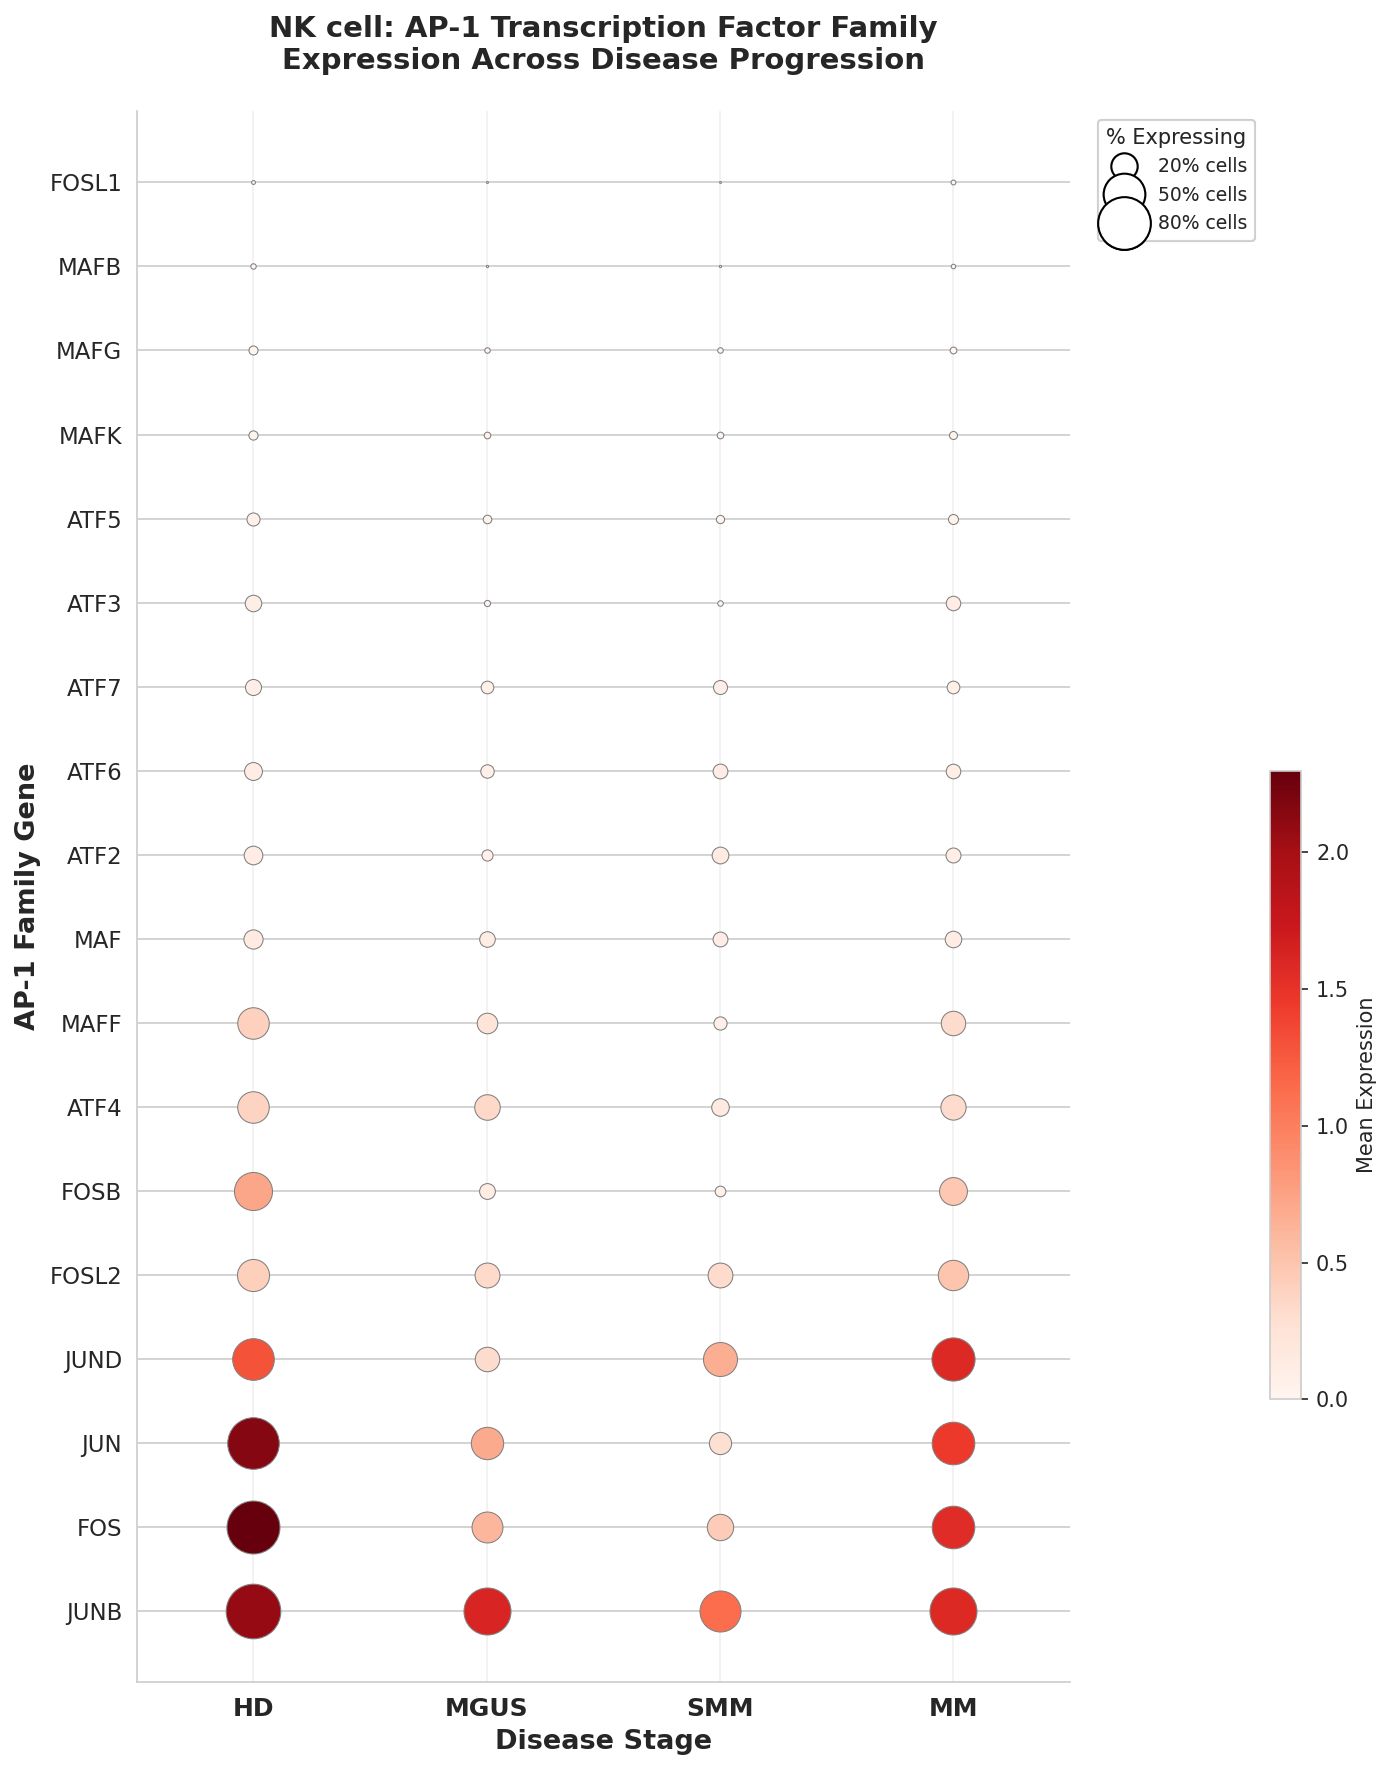

In [17]:
# ============================================================
# CELL 6: AP-1 DOT PLOT  (fixed indentation + PDF/TIFF/PNG save)
# ============================================================
import os
import matplotlib as mpl

# Embed fonts as TrueType so the PDF stays editable in Illustrator.
# Matplotlib's default (Type 3) is rejected by many journals.
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42

if len(available_ap1) > 0:

    avg_expr     = ap1_expr.mean(axis=1).sort_values(ascending=False)
    genes_sorted = avg_expr.index.tolist()
    max_expr     = float(ap1_expr.max().max())

    fig, ax = plt.subplots(
        figsize=(10, len(genes_sorted) * 0.55 + 2),
        dpi=150,
    )

    for i, gene in enumerate(genes_sorted):
        for j, disease in enumerate(disease_order):
            mean_expr = float(ap1_expr.loc[gene, disease])
            pct_expr  = float(ap1_pct.loc[gene, disease])
            size      = pct_expr * 8
            color     = plt.cm.Reds(mean_expr / max_expr if max_expr > 0 else 0)
            ax.scatter(j, i, s=size, c=[color],
                       edgecolors='grey', linewidth=0.5, zorder=2)

    ax.set_yticks(range(len(genes_sorted)))
    ax.set_yticklabels(genes_sorted, fontsize=11)
    ax.set_xticks(range(len(disease_order)))
    ax.set_xticklabels(disease_order, fontsize=12, fontweight='bold')
    ax.set_xlabel('Disease Stage', fontsize=13, fontweight='bold')
    ax.set_ylabel('AP-1 Family Gene', fontsize=13, fontweight='bold')
    ax.set_title(
        'NK cell: AP-1 Transcription Factor Family\n'
        'Expression Across Disease Progression',
        fontsize=14, fontweight='bold', pad=20,
    )
    ax.set_xlim(-0.5, len(disease_order) - 0.5)
    ax.grid(alpha=0.3, axis='x')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # size legend — markersize is a DIAMETER in points, scatter s is an AREA
    # in points^2, so sqrt(s) makes the keys match the plotted dots
    pct_levels  = [20, 50, 80]
    size_levels = [p * 8 for p in pct_levels]
    size_legend = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='white', markeredgecolor='black',
               markeredgewidth=1, markersize=np.sqrt(s),
               label=f'{p}% cells')
        for s, p in zip(size_levels, pct_levels)
    ]
    legend1 = ax.legend(
        handles=size_legend, loc='upper left', bbox_to_anchor=(1.02, 1),
        title='% Expressing', frameon=True, fontsize=9, title_fontsize=10,
    )
    ax.add_artist(legend1)

    sm = plt.cm.ScalarMappable(cmap='Reds', norm=plt.Normalize(0, max_expr))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.4, pad=0.15, anchor=(0, 0.3))
    cbar.set_label('Mean Expression', fontsize=10)

    plt.tight_layout()

    save_dir  = '/content/drive/My Drive/scRNAseq data/figures'
    os.makedirs(save_dir, exist_ok=True)
    save_name = f'AP1_dotplot_{CELL_TYPE}_FIXED'

    for ext in ['pdf', 'tiff', 'png']:
        filepath = os.path.join(save_dir, f'{save_name}.{ext}')
        fig.savefig(filepath, dpi=300, bbox_inches='tight', format=ext)
        print(f'Saved: {filepath} ({os.path.getsize(filepath) / 1024:.1f} KB)')

    plt.show()

else:
    print('No AP-1 genes available — nothing plotted.')

Exhaustion genes available: ['LAG3', 'TIGIT', 'KLRG1', 'KLRC1', 'CISH', 'PDCD1']


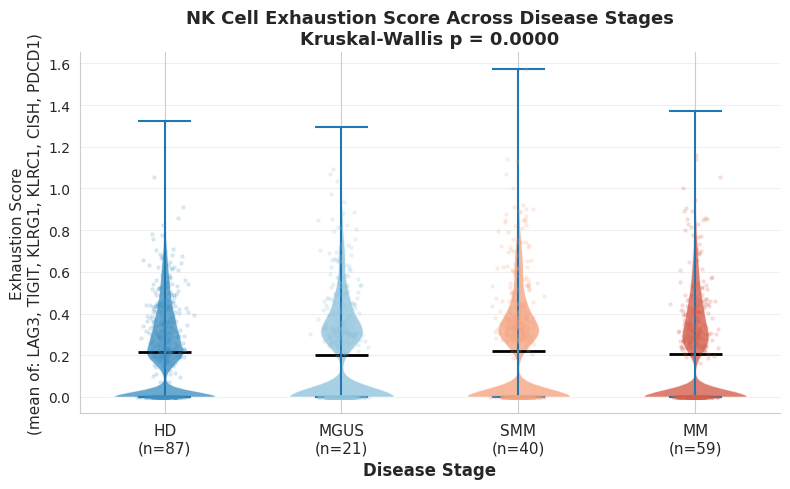

Saved: exhaustion_score_NK cell_disease_stages.png

Mean exhaustion score per disease stage:
-------------------------------------------------------
  HD    : mean=0.2174 | 87 patients | 29,966 cells
  MGUS  : mean=0.1988 | 21 patients | 2,856 cells
  SMM   : mean=0.2205 | 40 patients | 7,996 cells
  MM    : mean=0.2068 | 59 patients | 14,874 cells


In [9]:
# ============================================================
# CELL 7: NK EXHAUSTION SCORE ACROSS DISEASE STAGES
# ============================================================

exhaustion_genes_list = ['LAG3', 'TIGIT', 'KLRG1', 'KLRC1', 'CISH', 'PDCD1']
avail_exhaust = [g for g in exhaustion_genes_list if g in cells.var_names]

print(f'Exhaustion genes available: {avail_exhaust}')

if len(avail_exhaust) > 0:

    # Calculate per-cell exhaustion score (mean of available genes)
    exhaust_expr = []
    for gene in avail_exhaust:
        expr = cells[:, gene].X
        if sp.issparse(expr):
            expr = expr.toarray().flatten()
        else:
            expr = np.array(expr).flatten()
        exhaust_expr.append(expr)

    exhaust_matrix = np.vstack(exhaust_expr).T   # cells x genes
    exhaust_score  = exhaust_matrix.mean(axis=1)
    cells.obs['exhaustion_score'] = exhaust_score

    # Colors per stage
    colors_stage = {
        'HD':   '#4393c3',
        'MGUS': '#92c5de',
        'SMM':  '#f4a582',
        'MM':   '#d6604d'
    }

    plot_data  = []
    positions  = []
    labels_pos = []

    for j, disease in enumerate(disease_order):
        dc = cells[cells.obs['disease_category'] == disease]
        if dc.n_obs > 0:
            scores = dc.obs['exhaustion_score'].values
            plot_data.append(scores)
            positions.append(j)
            n_pat = dc.obs['sample_id'].nunique()
            labels_pos.append(f'{disease}\n(n={n_pat})')

    fig, ax = plt.subplots(figsize=(8, 5))

    parts = ax.violinplot(plot_data, positions=positions,
                          showmeans=True, showextrema=True,
                          widths=0.6)

    for pc, disease in zip(parts['bodies'], disease_order):
        pc.set_facecolor(colors_stage[disease])
        pc.set_alpha(0.8)

    parts['cmeans'].set_color('black')
    parts['cmeans'].set_linewidth(2)

    # Jittered points (subsampled)
    for j, (scores, disease) in enumerate(zip(plot_data, disease_order)):
        if len(scores) > 500:
            idx = np.random.choice(len(scores), 500, replace=False)
            scores_plot = scores[idx]
        else:
            scores_plot = scores
        ax.scatter(
            np.random.normal(j, 0.05, size=len(scores_plot)),
            scores_plot,
            alpha=0.15, s=5,
            color=colors_stage[disease], zorder=2
        )

    # Kruskal-Wallis overall test
    kw_stat, kw_p = stats.kruskal(*plot_data)

    ax.set_title(
        f'NK Cell Exhaustion Score Across Disease Stages\n'
        f'Kruskal-Wallis p = {kw_p:.4f}',
        fontsize=13, fontweight='bold'
    )
    ax.set_xticks(positions)
    ax.set_xticklabels(labels_pos, fontsize=11)
    ax.set_ylabel(
        f'Exhaustion Score\n(mean of: {", ".join(avail_exhaust)})',
        fontsize=11
    )
    ax.set_xlabel('Disease Stage', fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(f'exhaustion_score_{CELL_TYPE}_disease_stages.png',
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: exhaustion_score_{CELL_TYPE}_disease_stages.png')

    # Summary table
    print('\nMean exhaustion score per disease stage:')
    print('-' * 55)
    for disease in disease_order:
        dc = cells[cells.obs['disease_category'] == disease]
        if dc.n_obs > 0:
            mean_s = dc.obs['exhaustion_score'].mean()
            n_pat  = dc.obs['sample_id'].nunique()
            print(f'  {disease:<6}: mean={mean_s:.4f} | '
                  f'{n_pat} patients | {dc.n_obs:,} cells')

else:
    print('No exhaustion genes found in dataset')

In [10]:
# ============================================================
# PAIRWISE COMPARISONS — Mann-Whitney U test with BH correction
# ============================================================
from itertools import combinations
from scipy.stats import mannwhitneyu
import statsmodels.stats.multitest as multitest

# Get scores per group
group_scores = {}
for disease in disease_order:
    dc = cells[cells.obs['disease_category'] == disease]
    if dc.n_obs > 0:
        group_scores[disease] = dc.obs['exhaustion_score'].values

# All pairwise comparisons
pairs      = list(combinations(disease_order, 2))
p_values   = []
pair_names = []

for g1, g2 in pairs:
    if g1 in group_scores and g2 in group_scores:
        stat, p = mannwhitneyu(group_scores[g1], group_scores[g2],
                               alternative='two-sided')
        p_values.append(p)
        pair_names.append(f'{g1} vs {g2}')

# BH correction
reject, p_adj, _, _ = multitest.multipletests(p_values, method='fdr_bh')

# Print results
print('=' * 55)
print('PAIRWISE COMPARISONS — Mann-Whitney U (BH corrected)')
print('=' * 55)
for name, p_raw, p_corr, rej in zip(pair_names, p_values, p_adj, reject):
    sig = '****' if p_corr < 0.0001 else \
          '***'  if p_corr < 0.001  else \
          '**'   if p_corr < 0.01   else \
          '*'    if p_corr < 0.05   else 'ns'
    print(f'  {name:<20}: p={p_raw:.2e}  p_adj={p_corr:.2e}  {sig}')

PAIRWISE COMPARISONS — Mann-Whitney U (BH corrected)
  HD vs MGUS          : p=1.94e-07  p_adj=5.82e-07  ****
  HD vs SMM           : p=1.78e-01  p_adj=2.13e-01  ns
  HD vs MM            : p=3.66e-19  p_adj=2.20e-18  ****
  MGUS vs SMM         : p=1.39e-04  p_adj=2.08e-04  ***
  MGUS vs MM          : p=3.90e-01  p_adj=3.90e-01  ns
  SMM vs MM           : p=6.10e-06  p_adj=1.22e-05  ****


In [11]:
# ============================================================
# MEDIAN EXHAUSTION SCORE PER DISEASE STAGE
# ============================================================
print('=' * 55)
print('MEDIAN EXHAUSTION SCORE PER DISEASE STAGE')
print('=' * 55)
for disease in disease_order:
    dc = cells[cells.obs['disease_category'] == disease]
    if dc.n_obs > 0:
        scores = dc.obs['exhaustion_score'].values
        print(f'  {disease:<6}: '
              f'median={np.median(scores):.4f}  '
              f'mean={np.mean(scores):.4f}  '
              f'IQR={np.percentile(scores,25):.4f}–{np.percentile(scores,75):.4f}')

MEDIAN EXHAUSTION SCORE PER DISEASE STAGE
  HD    : median=0.2025  mean=0.2174  IQR=0.0000–0.3525
  MGUS  : median=0.0000  mean=0.1988  IQR=0.0000–0.3464
  SMM   : median=0.2158  mean=0.2205  IQR=0.0000–0.3713
  MM    : median=0.0000  mean=0.2068  IQR=0.0000–0.3695


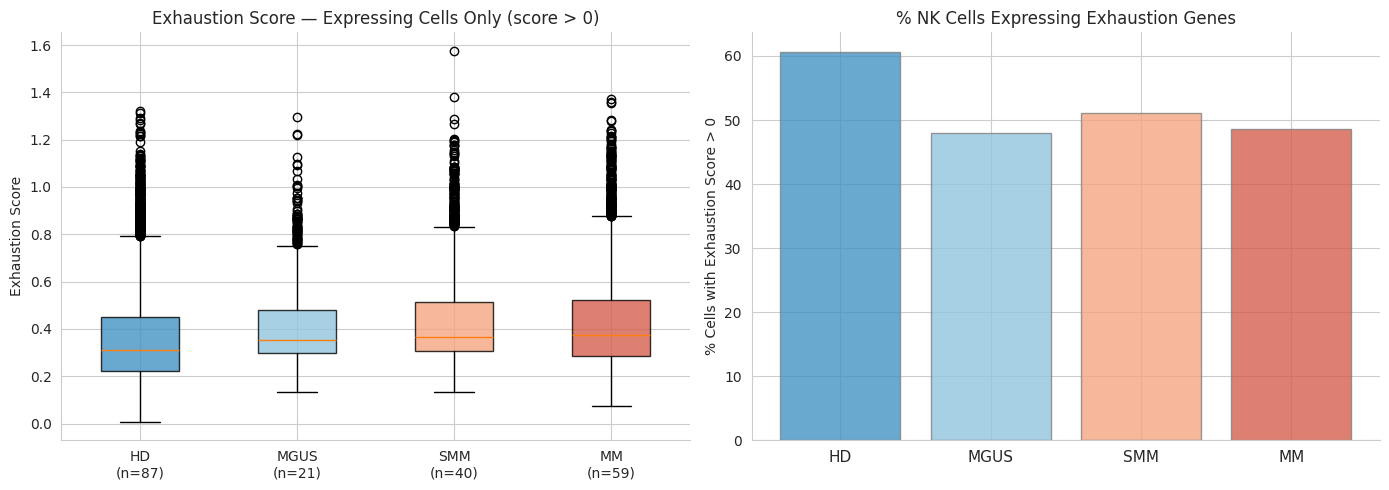

In [12]:
# Log-scale or zoom in on expressing cells only
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: only cells with score > 0
for j, (scores, disease) in enumerate(zip(plot_data, disease_order)):
    scores_pos = scores[scores > 0]
    axes[0].boxplot(scores_pos, positions=[j], widths=0.5,
                    patch_artist=True,
                    boxprops=dict(facecolor=colors_stage[disease], alpha=0.8))

axes[0].set_xticks(range(len(disease_order)))
axes[0].set_xticklabels(labels_pos)
axes[0].set_title('Exhaustion Score — Expressing Cells Only (score > 0)')
axes[0].set_ylabel('Exhaustion Score')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: % cells with score > 0
pct_expressing = []
for disease in disease_order:
    dc = cells[cells.obs['disease_category'] == disease]
    scores = dc.obs['exhaustion_score'].values
    pct_expressing.append((scores > 0).sum() / len(scores) * 100)

axes[1].bar(range(len(disease_order)), pct_expressing,
            color=[colors_stage[d] for d in disease_order],
            alpha=0.8, edgecolor='grey')
axes[1].set_xticks(range(len(disease_order)))
axes[1].set_xticklabels(disease_order, fontsize=11)
axes[1].set_ylabel('% Cells with Exhaustion Score > 0')
axes[1].set_title('% NK Cells Expressing Exhaustion Genes')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('exhaustion_score_expressing_cells.png', dpi=300, bbox_inches='tight')
plt.show()

EXHAUSTION SCORE — EXPRESSING CELLS ONLY (score > 0)
  HD    : n=18,178  median=0.3118  mean=0.3583  IQR=0.2220–0.4506
  MGUS  : n=1,371  median=0.3522  mean=0.4140  IQR=0.2969–0.4817
  SMM   : n=4,082  median=0.3679  mean=0.4319  IQR=0.3051–0.5159
  MM    : n=7,235  median=0.3763  mean=0.4251  IQR=0.2848–0.5212

Pairwise comparisons (BH-corrected):
  HD vs MGUS  : p_adj=2.78e-49  ****
  HD vs SMM   : p_adj=6.79e-172  ****
  HD vs MM    : p_adj=3.35e-194  ****
  MGUS vs SMM   : p_adj=1.28e-03  **
  MGUS vs MM    : p_adj=4.44e-01  ns
  SMM vs MM    : p_adj=8.11e-04  ***


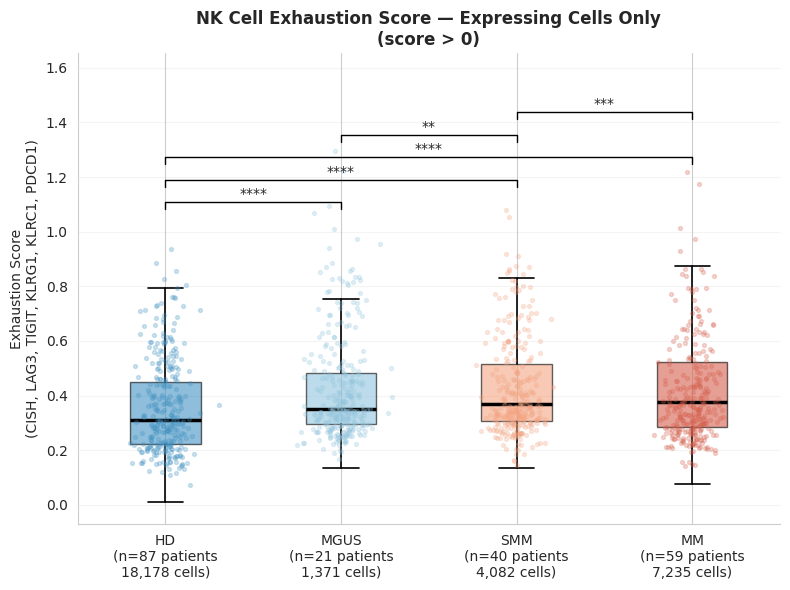

Saved: exhaustion_boxplot_FINAL (PDF, TIFF, PNG)


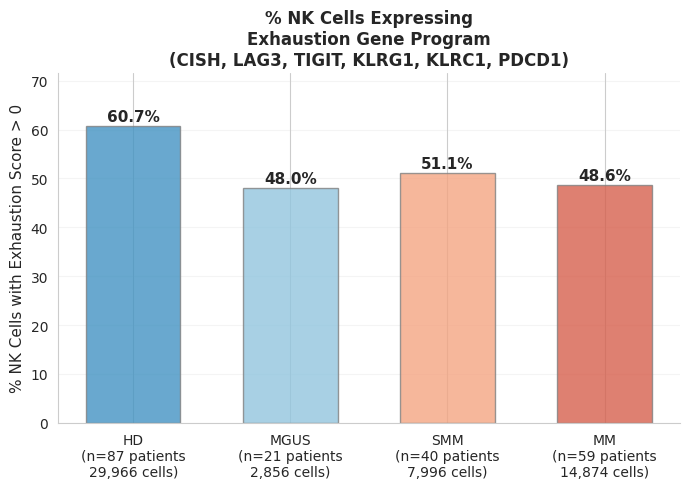

Saved: exhaustion_pct_expressing_FINAL (PDF, TIFF, PNG)
Saved to Drive: exhaustion_boxplot_FINAL.pdf
Saved to Drive: exhaustion_boxplot_FINAL.tiff
Saved to Drive: exhaustion_boxplot_FINAL.png
Saved to Drive: exhaustion_pct_expressing_FINAL.pdf
Saved to Drive: exhaustion_pct_expressing_FINAL.tiff
Saved to Drive: exhaustion_pct_expressing_FINAL.png


In [13]:
from itertools import combinations
import statsmodels.stats.multitest as multitest
from scipy.stats import mannwhitneyu

# ============================================================
# PREPARE DATA
# ============================================================
plot_data_pos  = []
labels_pos_new = []

for disease in disease_order:
    dc         = cells[cells.obs['disease_category'] == disease]
    scores     = dc.obs['exhaustion_score'].values
    scores_pos = scores[scores > 0]
    plot_data_pos.append(scores_pos)
    n_pat    = dc.obs['sample_id'].nunique()
    n_cells  = len(scores_pos)
    labels_pos_new.append(f'{disease}\n(n={n_pat} patients\n{n_cells:,} cells)')

# Pairwise stats
pairs      = list(combinations(range(len(disease_order)), 2))
p_raw_list = []
pair_idx   = []

for i, j in pairs:
    if len(plot_data_pos[i]) > 0 and len(plot_data_pos[j]) > 0:
        _, p = mannwhitneyu(plot_data_pos[i], plot_data_pos[j],
                            alternative='two-sided')
        p_raw_list.append(p)
        pair_idx.append((i, j))

_, p_adj_list, _, _ = multitest.multipletests(p_raw_list, method='fdr_bh')

# Print summary stats
print('=' * 65)
print('EXHAUSTION SCORE — EXPRESSING CELLS ONLY (score > 0)')
print('=' * 65)
for disease, scores_pos in zip(disease_order, plot_data_pos):
    print(f'  {disease:<6}: n={len(scores_pos):,}  '
          f'median={np.median(scores_pos):.4f}  '
          f'mean={np.mean(scores_pos):.4f}  '
          f'IQR={np.percentile(scores_pos,25):.4f}–'
          f'{np.percentile(scores_pos,75):.4f}')

print('\nPairwise comparisons (BH-corrected):')
for (i, j), p_corr in zip(pair_idx, p_adj_list):
    sig = '****' if p_corr < 0.0001 else \
          '***'  if p_corr < 0.001  else \
          '**'   if p_corr < 0.01   else \
          '*'    if p_corr < 0.05   else 'ns'
    print(f'  {disease_order[i]} vs {disease_order[j]:<6}: '
          f'p_adj={p_corr:.2e}  {sig}')

# ============================================================
# FIGURE 1: BOXPLOT — expressing cells only
# ============================================================
fig1, ax = plt.subplots(figsize=(8, 6))

for j, (scores_pos, disease) in enumerate(zip(plot_data_pos, disease_order)):

    # Boxplot — no mean line
    ax.boxplot(scores_pos, positions=[j], widths=0.4,
               patch_artist  = True,
               boxprops      = dict(facecolor=colors_stage[disease], alpha=0.6),
               medianprops   = dict(color='black', linewidth=2.5),
               whiskerprops  = dict(color='black', linewidth=1.2),
               capprops      = dict(color='black', linewidth=1.2),
               flierprops    = dict(marker='', linestyle='none'))

    # Jittered dots
    if len(scores_pos) > 300:
        idx       = np.random.choice(len(scores_pos), 300, replace=False)
        dots_plot = scores_pos[idx]
    else:
        dots_plot = scores_pos

    ax.scatter(
        np.random.normal(j, 0.08, size=len(dots_plot)),
        dots_plot,
        alpha=0.25, s=8,
        color=colors_stage[disease], zorder=3
    )

# Significance brackets — only significant pairs
y_max   = max([np.percentile(s, 99) for s in plot_data_pos])
y_step  = y_max * 0.08
y_start = y_max * 1.05

bracket_count = 0
for (i, j), p_corr in zip(pair_idx, p_adj_list):
    sig = '****' if p_corr < 0.0001 else \
          '***'  if p_corr < 0.001  else \
          '**'   if p_corr < 0.01   else \
          '*'    if p_corr < 0.05   else 'ns'
    if sig == 'ns':
        continue
    y = y_start + bracket_count * y_step
    ax.plot([i, i, j, j],
            [y, y + y_step*0.3, y + y_step*0.3, y],
            'k-', linewidth=1)
    ax.text((i + j) / 2, y + y_step*0.35,
            sig, ha='center', va='bottom', fontsize=10)
    bracket_count += 1

ax.set_xticks(range(len(disease_order)))
ax.set_xticklabels(labels_pos_new, fontsize=10)
ax.set_title('NK Cell Exhaustion Score — Expressing Cells Only\n'
             '(score > 0)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Exhaustion Score\n(CISH, LAG3, TIGIT, KLRG1, KLRC1, PDCD1)',
              fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2, axis='y')

plt.tight_layout()

# Save Figure 1
for ext in ['pdf', 'tiff', 'png']:
    plt.savefig(f'exhaustion_boxplot_FINAL.{ext}',
                dpi=300, bbox_inches='tight', format=ext)

plt.show()
print('Saved: exhaustion_boxplot_FINAL (PDF, TIFF, PNG)')

# ============================================================
# FIGURE 2: BAR CHART — % expressing cells
# ============================================================
fig2, ax2 = plt.subplots(figsize=(7, 5))

pct_expressing = []
n_cells_list   = []

for disease in disease_order:
    dc     = cells[cells.obs['disease_category'] == disease]
    scores = dc.obs['exhaustion_score'].values
    pct    = (scores > 0).sum() / len(scores) * 100
    pct_expressing.append(pct)
    n_cells_list.append(len(scores))

bars = ax2.bar(range(len(disease_order)), pct_expressing,
               color=[colors_stage[d] for d in disease_order],
               alpha=0.8, edgecolor='grey', width=0.6)

# % labels on top of bars
for bar, pct in zip(bars, pct_expressing):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'{pct:.1f}%',
             ha='center', va='bottom',
             fontsize=11, fontweight='bold')

# x-axis labels with patient and cell counts
labels_bar = []
for disease, n_cells in zip(disease_order, n_cells_list):
    dc    = cells[cells.obs['disease_category'] == disease]
    n_pat = dc.obs['sample_id'].nunique()
    labels_bar.append(f'{disease}\n(n={n_pat} patients\n{n_cells:,} cells)')

ax2.set_xticks(range(len(disease_order)))
ax2.set_xticklabels(labels_bar, fontsize=10)
ax2.set_ylabel('% NK Cells with Exhaustion Score > 0', fontsize=11)
ax2.set_title('% NK Cells Expressing\nExhaustion Gene Program\n'
              '(CISH, LAG3, TIGIT, KLRG1, KLRC1, PDCD1)',
              fontsize=12, fontweight='bold')
ax2.set_ylim(0, max(pct_expressing) * 1.18)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(alpha=0.2, axis='y')

plt.tight_layout()

# Save Figure 2
for ext in ['pdf', 'tiff', 'png']:
    plt.savefig(f'exhaustion_pct_expressing_FINAL.{ext}',
                dpi=300, bbox_inches='tight', format=ext)

plt.show()
print('Saved: exhaustion_pct_expressing_FINAL (PDF, TIFF, PNG)')

import shutil, os

output_folder = '/content/drive/My Drive/NK_AP1_Exhaustion_RevisionAnalysis'
os.makedirs(output_folder, exist_ok=True)

for fname in [
    'exhaustion_boxplot_FINAL.pdf',
    'exhaustion_boxplot_FINAL.tiff',
    'exhaustion_boxplot_FINAL.png',
    'exhaustion_pct_expressing_FINAL.pdf',
    'exhaustion_pct_expressing_FINAL.tiff',
    'exhaustion_pct_expressing_FINAL.png'
]:
    shutil.copy(fname, os.path.join(output_folder, fname))
    print(f'Saved to Drive: {fname}')

In [14]:
# Check available metadata columns
print(cells.obs.columns.tolist())

# Check if there are NK subtypes or cluster annotations
for col in ['cell_type', 'leiden', 'louvain', 'cluster', 'subtype', 'celltype']:
    if col in cells.obs.columns:
        print(f'\n--- {col} ---')
        print(cells.obs.groupby(['disease_category', col]).size().unstack(fill_value=0))

['sample_id', 'study_id', 'donor_id', 'barcode', 'tissue', 'chem', 'sort', 'has_tcr', 'n_counts', 'log10_counts', 'n_genes', 'pct_counts_mt', 'pct_counts_hb', 'pct_counts_ig', 'scr_doublet', 'scr_doublet_score', 'UMAP1', 'UMAP2', 'MDE1', 'MDE2', 'leiden_0.6', 'lineage', 'pheno', 'disease_category', 'exhaustion_score']


In [15]:
# Check pheno column — likely has NK subtypes
print('--- pheno labels ---')
print(cells.obs['pheno'].value_counts())

print('\n--- pheno by disease stage ---')
print(cells.obs.groupby(['disease_category', 'pheno']).size().unstack(fill_value=0))

# Check leiden clusters
print('\n--- leiden_0.6 by disease stage ---')
print(cells.obs.groupby(['disease_category', 'leiden_0.6']).size().unstack(fill_value=0))

--- pheno labels ---
pheno
NK cell    56047
Name: count, dtype: int64

--- pheno by disease stage ---
pheno             NK cell
disease_category         
HD                  29966
MGUS                 2856
MM                  14874
SMM                  7996
Unknown               355

--- leiden_0.6 by disease stage ---
leiden_0.6            5
disease_category       
HD                29966
MGUS               2856
MM                14874
SMM                7996
Unknown             355


In [16]:
# ============================================================
# CELL 8: SAVE TO GOOGLE DRIVE
# ============================================================
import shutil, os, glob

output_folder = f'/content/drive/My Drive/NK_AP1_Exhaustion_RevisionAnalysis'
os.makedirs(output_folder, exist_ok=True)

all_files = glob.glob('*.png') + glob.glob('*.csv')
print(f'Saving {len(all_files)} files to Google Drive...')

for f in all_files:
    try:
        shutil.copy(f, os.path.join(output_folder, f))
        print(f'  Saved: {f}')
    except Exception as e:
        print(f'  Error saving {f}: {e}')

print(f'\nAll files saved to: {output_folder}')

Saving 5 files to Google Drive...
  Saved: exhaustion_score_expressing_cells.png
  Saved: AP1_dotplot_NK cell_FIXED.png
  Saved: exhaustion_score_NK cell_disease_stages.png
  Saved: exhaustion_boxplot_FINAL.png
  Saved: exhaustion_pct_expressing_FINAL.png

All files saved to: /content/drive/My Drive/NK_AP1_Exhaustion_RevisionAnalysis
